In [ ]:
# IQR Method is only applicable for skewed distribution (right or lef skewed) 
# for other distribution, this method may not detect outliers effeciently.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as pyplot 
import seaborn as sns 

In [2]:
df = pd.read_csv('placement.csv')
df.sample(5)

,cgpa,placement_exam_marks,placed
457,6.58,20.0,0
728,6.63,23.0,0
605,6.64,42.0,0
97,7.33,52.0,1
780,5.62,31.0,0


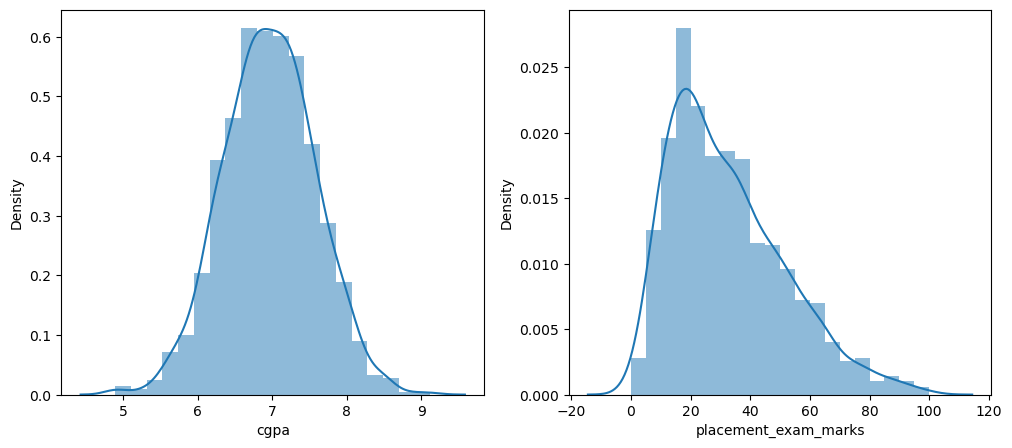

In [3]:
pyplot.figure(figsize=(12,5))
pyplot.subplot(121)
sns.histplot(x=df['cgpa'], bins=20, alpha=0.5,stat='density', linewidth=0)
sns.kdeplot(x=df['cgpa'])                     # cgpa is having near-normal Distribution

pyplot.subplot(122)
sns.histplot(x=df['placement_exam_marks'], bins=20, alpha=0.5,stat='density', edgecolor='none')
sns.kdeplot(x=df['placement_exam_marks'])     # placement_exam_marks have Right Skewed Distribution
pyplot.show()

In [6]:
df['placement_exam_marks'].skew()    # right skewed

np.float64(0.8356419499466834)

In [7]:
df['placement_exam_marks'].describe()           # mean, std, min, max, 25th and 75th percentile

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

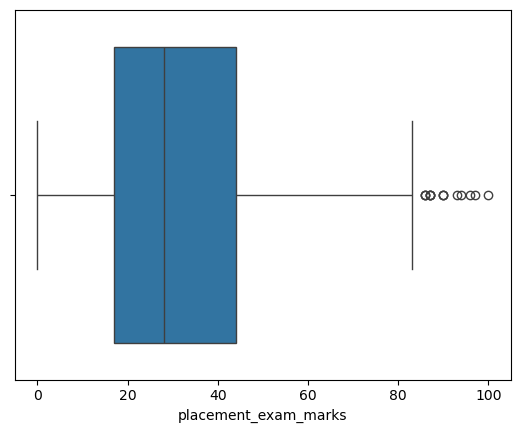

In [15]:
# BoxPlot
sns.boxplot(x=df['placement_exam_marks'])        
# as we can observe that in this outliers are only on the  upper_limit side

In [16]:
# finding the IQR of df['placement_exam_marks']   

percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

percentile25, percentile75

(np.float64(17.0), np.float64(44.0))

In [17]:
# finding the Outliers 
iqr = percentile75 - percentile25 

upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

print("upper limit :", upper_limit)
print("lower limit :", lower_limit)

upper limit : 84.5
lower limit : -23.5


<h2 style='color:red'>Finding Outliers</h2>

In [21]:
df[df['placement_exam_marks'] > upper_limit]     # 15 outliers above upper_limit

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [22]:
df[df['placement_exam_marks'] < lower_limit]            # no outliers below lower_limit

,cgpa,placement_exam_marks,placed


<h2 style='color:red'>Trimming</h2>

In [33]:
# Completely removing the outliers from the Dataset  
new_df = df[df['placement_exam_marks'] < upper_limit]

new_df.shape

(985, 3)

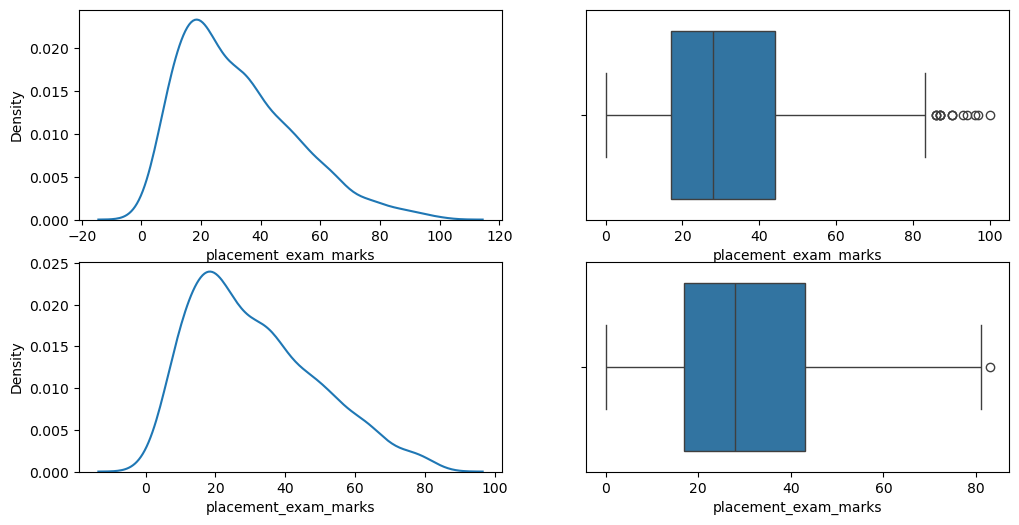

In [34]:
# Comparing before and after removing outliers
pyplot.figure(figsize=(12,6))
pyplot.subplot(221)
sns.kdeplot(x=df['placement_exam_marks'])

pyplot.subplot(222)
sns.boxplot(x=df['placement_exam_marks'])

pyplot.subplot(223)
sns.kdeplot(x=new_df['placement_exam_marks'])

pyplot.subplot(224)
sns.boxplot(x=new_df['placement_exam_marks'])

pyplot.show()

<h2 style='color:red'>Capping</h2>

In [35]:
# Capping - not let any value to go outside min to max value range without dropping them. 

In [36]:
cap_df = df.copy() 

cap_df['placement_exam_marks'] = np.where(
        df['placement_exam_marks'] > upper_limit,                # condition
        upper_limit,                                             # if true    (cgpa > upper_limit, replace df['cgpa'] value by upper_limit)
        np.where(                                                # if false
                 df['placement_exam_marks'] < lower_limit,             # condition
                 lower_limit,                                          # if true
                 df['placement_exam_marks']                            # if false
                )
       ) 


In [40]:
cap_df.shape

(1000, 3)

In [39]:
cap_df['placement_exam_marks'].describe()

count    1000.000000
mean       32.136500
std        18.865419
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max        84.500000
Name: placement_exam_marks, dtype: float64

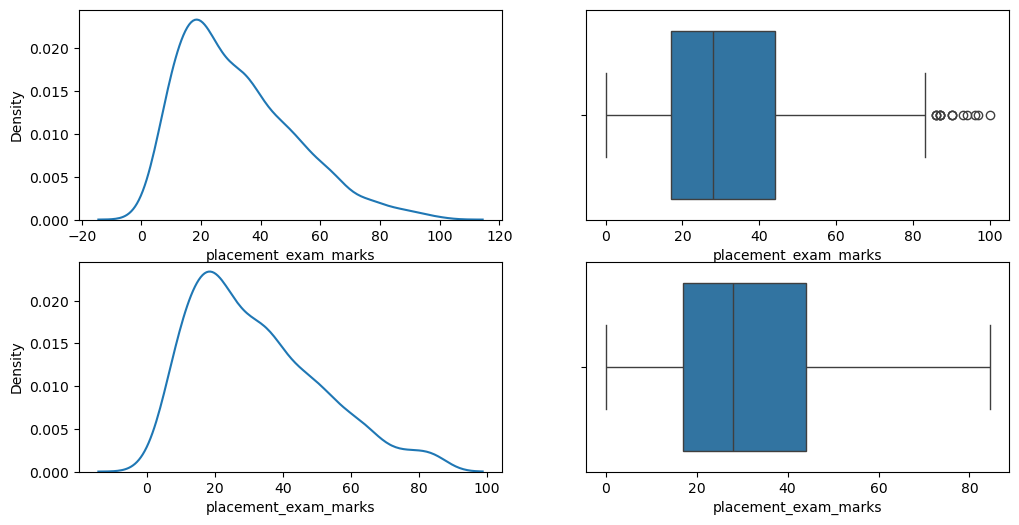

In [42]:
# Comparing before and after removing outliers
pyplot.figure(figsize=(12,6))
pyplot.subplot(221)
sns.kdeplot(x=df['placement_exam_marks'])

pyplot.subplot(222)
sns.boxplot(x=df['placement_exam_marks'])

pyplot.subplot(223)
sns.kdeplot(x=cap_df['placement_exam_marks'])           # distribution near upper_limit=84.5 increases 

pyplot.subplot(224)
sns.boxplot(x=cap_df['placement_exam_marks'])

pyplot.show()